In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, random_split
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

def train_tensor4_reconstruction_gd(p: int,
                                    H: int,
                                    sigma2: float,
                                    T: float,
                                    num_epochs: int,
                                    batch_size: int,
                                    t_max=None,
                                    no_target: bool = True,
                                    device: str = "cuda:0",
                                    seed: int | None = None):
    """
    Analytic full-batch GD for order-4 tensor reconstruction with shared CP factors.

    Objective:
        pred[i,j,k,l] = sum_h u[h,i] u[h,j] u[h,k] u[h,l]

    Let G = u @ u.T, shape H x H.

    If no_target=True:
        L = 1/2 sum_{a,b} G[a,b]^4
        grad = 4 * G^{circ 3} @ u

    If no_target=False, target is the diagonal order-4 identity:
        L = 1/2 sum_{a,b} G[a,b]^4 - sum_{h,i} u[h,i]^4 + p/2
        grad = 4 * G^{circ 3} @ u - 4 * u^{circ 3}
    """

    # Set seed if requested
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # Time grid
    if t_max is None:
        t_max = num_epochs

    t_arr, tau = np.linspace(0, t_max, num_epochs + 1, retstep=True)
    tau = t_arr[1] - t_arr[0]

    dev = torch.device(device if torch.cuda.is_available() else "cpu")
    sigma = float(sigma2) ** 0.5

    # Parameter tensor
    u = torch.randn(H, p, device=dev) * sigma

    lr = abs(tau / T)
    step_sign = 1.0 if tau < 0 else -1.0

    epoch_loss_hist = []

    # Internal memory guard:
    # for ordinary experiment sizes, use full H x H Gram;
    # for very large H, compute gradient in chunks.
    max_gram_entries = max(int(batch_size), 100_000_000)

    with torch.no_grad():
        for epoch in tqdm(range(1, num_epochs + 1)):
            # Fast path: materialize full Gram matrix
            if H * H <= max_gram_entries:
                G = u @ u.T                         # H x H
                G3 = G * G * G                      # elementwise cube

                loss = 0.5 * torch.sum(G3 * G)      # 1/2 sum G^4
                grad = 4.0 * (G3 @ u)

            # Memory-safe path: chunk rows of G
            else:
                chunk_rows = max(1, max_gram_entries // H)
                loss = u.new_tensor(0.0)
                grad = torch.empty_like(u)

                for s in range(0, H, chunk_rows):
                    e = min(s + chunk_rows, H)

                    G_chunk = u[s:e] @ u.T
                    G3_chunk = G_chunk * G_chunk * G_chunk

                    loss = loss + 0.5 * torch.sum(G3_chunk * G_chunk)
                    grad[s:e] = 4.0 * (G3_chunk @ u)

            if not no_target:
                u2 = u * u
                u3 = u2 * u
                u4 = u2 * u2

                loss = loss - torch.sum(u4) + 0.5 * p
                grad = grad - 4.0 * u3

            epoch_loss = float(loss.item())

            # Manual SGD step
            u.add_(grad, alpha=step_sign * lr)

            epoch_loss_hist.append(epoch_loss)

            if epoch_loss_hist[0] != 0 and epoch_loss / epoch_loss_hist[0] > 1.5:
                break

    return u.detach().cpu(), np.array(epoch_loss_hist), t_arr[:len(epoch_loss_hist)]

In [2]:
loss_hists = []
p = 64
H_list = [int(p**2*4),int(p**2),int(p**2/4)]
L_0 = 1.0
t_max = 100.0
num_iters = 4000
batch_size = int(2**18)

for H in H_list:
    theta = 1 + 3 * H/p**2
    sigma2 = (2*L_0/p**4/H/theta)**0.25
    T = 96 * (p * sigma2)**3
    u,loss_hist,t_arr = train_tensor4_reconstruction_gd(p, H, sigma2, T, num_iters,batch_size,t_max=t_max,no_target=True)
    loss_hists.append(loss_hist)

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

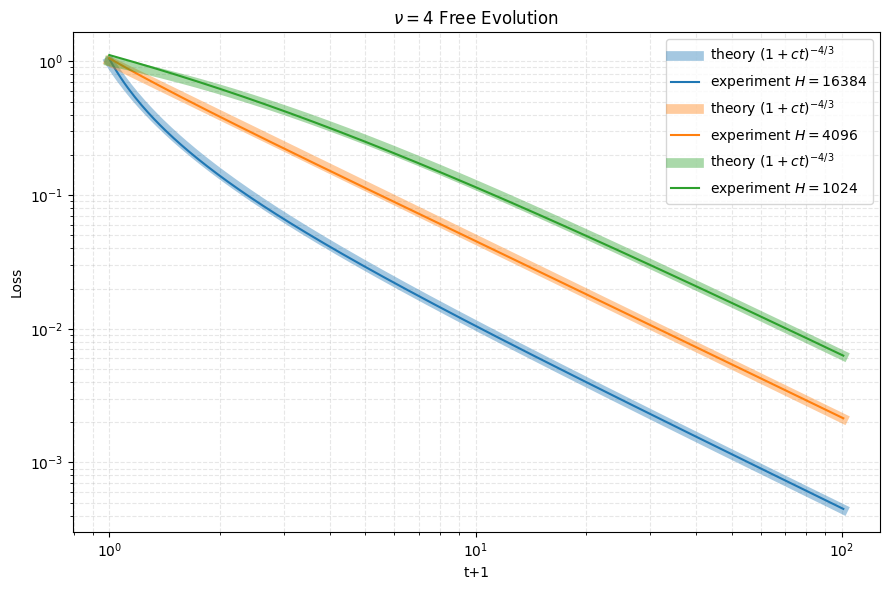

In [3]:
plt.figure(figsize=(9, 6))

for i,H in enumerate(H_list):
    theta = 1 + 3 * H/p**2
    c = 0.25 * theta
    theory_loss = L_0*(1+c*t_arr)**(-4/3)
    line, = plt.plot(t_arr+1, theory_loss,label=f'theory $(1+ct)^{{-4/3}}$', linewidth=7,alpha=0.4)
    plt.plot(t_arr+1, loss_hists[i], label=f'experiment $H={H}$',color=line.get_color())
    
#plt.ylim(-loss_curves[0].min()+p/2,-loss_curves[0].max()+p/2)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('t+1')
plt.ylabel('Loss')
plt.legend()
plt.title(f'$\\nu=4$ Free Evolution')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
np.save('loss_hists_nu4_free.npy',np.array(loss_hists))

In [6]:
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase,HandlerTuple

In [8]:
class MultiLineHandle:
    """Legend handle that stores a list of artists + a key."""
    def __init__(self, artists, key):
        self.artists = artists
        self.key = key

class HandlerMultiLinePad(HandlerBase):
    """Like HandlerTuple, but choose pad based on handle.key."""
    def __init__(self, pad_map=None, default_pad=0.25, ndivide=None, **kwargs):
        super().__init__(**kwargs)
        self.pad_map = pad_map or {}
        self.default_pad = default_pad
        self.ndivide = ndivide

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height,
                       fontsize, trans):
        pad = self.pad_map.get(orig_handle.key, self.default_pad)
        ht = HandlerTuple(ndivide=self.ndivide, pad=pad)
        # delegate to HandlerTuple using the stored artists
        return ht.create_artists(
            legend, tuple(orig_handle.artists),
            xdescent, ydescent, width, height, fontsize, trans
        )

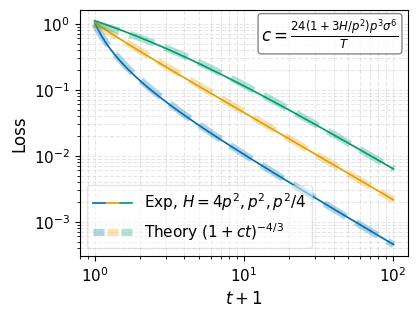

In [17]:
# ---------- Style ----------
xylabel_fs = 12
xyticks_fs = 11
legend_fs = 11
theory_lw = 5
theory_alpha = 0.3
exp_lw = 1.25

plt.rcParams.update({
    "font.size": xyticks_fs,
    "axes.labelsize": xylabel_fs,
    "xtick.labelsize": xyticks_fs,
    "ytick.labelsize": xyticks_fs,
    "legend.fontsize": legend_fs,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------- Colors ----------
color_list = ['#0072B2', '#E69F00', '#009E73']

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(4.0, 3.0))

theory_proxies = []
exp_proxies = []

for i, H in enumerate(H_list):
    col = color_list[i % len(color_list)]

    theta = 1 + 3 * H / p**2
    c = 0.25 * theta

    # theory
    theory_loss = L_0 * (1 + c * t_arr)**(-4/3)
    ax.plot(
        t_arr + 1,
        theory_loss,
        color=col,
        linestyle='--',
        linewidth=theory_lw,
        alpha=theory_alpha
    )

    # experiment
    ax.plot(
        t_arr + 1,
        loss_hists[i],
        color=col,
        linewidth=exp_lw
    )

    # legend proxies
    theory_proxies.append(
        Line2D([0], [0], lw=theory_lw, alpha=theory_alpha, color=col, linestyle='--')
    )
    exp_proxies.append(
        Line2D([0], [0], lw=exp_lw, color=col)
    )

# ---------- Axes cosmetics ----------
ax.set_xlabel(r'$t+1$')
ax.set_ylabel(r'Loss')

ax.set_xscale('log')
ax.set_yscale('log')

ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.tick_params(labelsize=xyticks_fs)

# ---------- Single legend: Exp + Theory ----------
exp_label = r'Exp, $H=4p^2,p^2,p^2/4$'
theory_label = r'Theory $(1+ct)^{-4/3}$'

exp_handle = MultiLineHandle(exp_proxies, key="exp")
theory_handle = MultiLineHandle(theory_proxies, key="theory")

pad_map = {"exp": 0.1, "theory": 0.25}

ax.legend(
    [exp_handle, theory_handle],
    [exp_label, theory_label],
    loc="lower left",
    frameon=True,
    framealpha=0.5,
    handlelength=2.5,
    handler_map={
        MultiLineHandle: HandlerMultiLinePad(
            pad_map=pad_map,
            default_pad=0.25,
            ndivide=None
        )
    },
    fontsize=legend_fs
)

bbox = dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="dimgray")

ax.text(0.97, 0.97, r'$c = \frac{24 (1+3 H/p^2) p^3 \sigma^6}{T}$',
             transform=ax.transAxes, ha='right', va='top',
             fontsize=xylabel_fs, bbox=bbox)

plt.tight_layout(pad=0.05)
plt.savefig(
    "Nu4-free-gen.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()